In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\apaks\Desktop\Real Estate Project\artifacts\data\preprocessed-data\gurgaon_properties_v3.csv')

In [3]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price_in_cr               0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 15
facing                  997
agePossession             0
super_built_up_area    1599
built_up_area          1975
carpet_area            1672
servant room              0
study room                0
pooja room                0
store room                0
others                    0
furnishing_type           0
luxury_score            390
area_bedroom_ratio        0
dtype: int64

### built_up_area columns

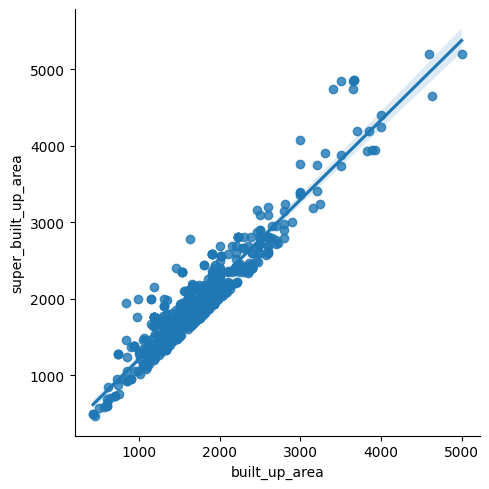

In [4]:
sns.lmplot(data = df, x = 'built_up_area', y = 'super_built_up_area')

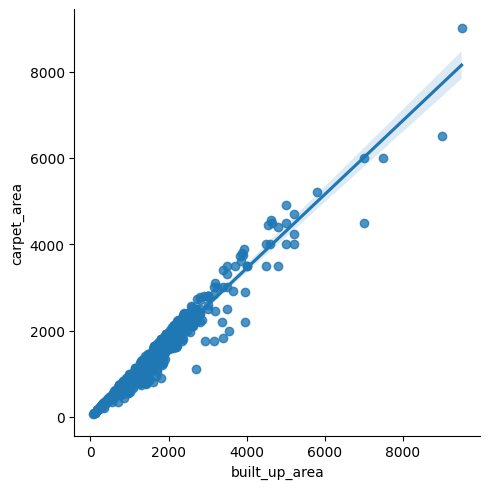

In [5]:
sns.lmplot(data = df, x = 'built_up_area', y = 'carpet_area')

- strong linear relation between built_up_area, super_built_up_area and carpet_area

In [6]:
# rows where all 3 areas are missing

df[(df['built_up_area'].isnull()) & (df['super_built_up_area'].isnull()) & (df['carpet_area'].isnull())]

,property_type,society,sector,price_in_cr,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,built_up_area,carpet_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score,area_bedroom_ratio


In [7]:
# rows where all the areas are present 

all_present_df = df[~((df['built_up_area'].isnull()) | (df['super_built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [8]:
all_present_df.shape

(532, 24)

In [9]:
# super_built_up_area vs built_up_area ration
# carpet_area vs built_up_area ratio

super_builtup_vs_builtup_ratio = (all_present_df['super_built_up_area'] / all_present_df['built_up_area']).median()
carpet_vs_builtup_ration = (all_present_df['carpet_area'] / all_present_df['built_up_area']).median()

print(super_builtup_vs_builtup_ratio, carpet_vs_builtup_ration)

1.1052289815447711 0.9071428571428571


In [10]:
# in rows where builtup area is not available and super built up and built up areas are present, we can calculate built_up_area by taking average of (super_built_up_area/1.10 + carpet_area / 0.90) --> average of prediction using the ratio of 2 other areas which the built up area is very much correlated with

temp_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area']).isnull() & ~(df['carpet_area'].isnull())]

In [11]:
pd.set_option('display.max_columns', None)

In [12]:
temp_df.head()

,property_type,society,sector,price_in_cr,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score,area_bedroom_ratio
0,flat,vatika gurgaon,sector 83,1.18,6801.00,1735.04,Super Built up area 1735(161.19 sq.m.)Carpet a...,3,3,2,14.0,north,relatively new,1735.0,NaN,1500.0,0,0,0,0,0,1,16.0,578.346667
2,flat,ss the leaf,sector 85,1.10,6317.99,1741.06,Super Built up area 1741(161.74 sq.m.)Carpet a...,2,2,3+,3.0,south-east,relatively new,1741.0,NaN,1218.0,0,0,0,1,0,1,117.0,870.530000
3,flat,tarc maceo,sector 91,0.89,6338.99,1404.01,Super Built up area 1404(130.44 sq.m.)Carpet a...,2,2,3+,9.0,east,relatively new,1404.0,NaN,1200.0,0,0,0,0,1,0,9.0,702.005000
11,flat,tulip violet,sector 69,1.51,9569.01,1578.01,Super Built up area 1578(146.6 sq.m.)Carpet ar...,3,3,2,0.0,west,relatively new,1578.0,NaN,1100.0,0,0,1,0,0,2,145.0,526.003333
41,flat,bestech park view ananda,sector 81,1.10,6686.00,1645.23,Super Built up area 1645(152.83 sq.m.)Carpet a...,3,2,3+,5.0,east,relatively new,1645.0,NaN,1034.0,0,0,0,0,0,1,125.0,548.410000


In [13]:
temp_df['built_up_area'] = temp_df['built_up_area'].fillna(round(((temp_df['super_built_up_area']/super_builtup_vs_builtup_ratio) + (temp_df['carpet_area']/carpet_vs_builtup_ration)) / 2))

In [14]:
temp_df['built_up_area'].isnull().sum()

np.int64(0)

In [15]:
df.update(temp_df)

In [16]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price_in_cr               0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 15
facing                  997
agePossession             0
super_built_up_area    1599
built_up_area          1553
carpet_area            1672
servant room              0
study room                0
pooja room                0
store room                0
others                    0
furnishing_type           0
luxury_score            390
area_bedroom_ratio        0
dtype: int64

In [17]:
# rows where super built up area is present, built up is null but carpet area is null

temp_df = df[(~df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [18]:
# built_up_area = (super_built_up_area/1.10)

temp_df['built_up_area'] = round(df['super_built_up_area']/1.10)

In [19]:
df.update(temp_df)

In [20]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price_in_cr               0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 15
facing                  997
agePossession             0
super_built_up_area    1599
built_up_area           656
carpet_area            1672
servant room              0
study room                0
pooja room                0
store room                0
others                    0
furnishing_type           0
luxury_score            390
area_bedroom_ratio        0
dtype: int64

In [21]:
# rows where super_built_up area is null but carpet area is present and built_up area is also not present

temp_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (~df['carpet_area'].isnull())]

In [22]:
temp_df.shape

(656, 24)

In [26]:
temp_df.head()

,property_type,society,sector,price_in_cr,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score,area_bedroom_ratio
4,flat,rwa,sector 7,0.48,6000.00,800.00,Carpet area: 800 (74.32 sq.m.),3,2,1,1.0,north-east,new,NaN,889.0,800.0,0,0,0,0,0,1,12.0,266.666667
10,flat,signature global city 92,sector 92,0.99,6621.98,1495.02,Carpet area: 1495 (138.89 sq.m.),3,2,3,1.0,east,new,NaN,1661.0,1495.0,0,0,0,0,1,1,18.0,498.340000
28,house,independent,sector 13,2.25,6943.99,3240.21,Carpet area: 360 (301.01 sq.m.),10,10,2,1.0,East,undefined,NaN,400.0,360.0,0,0,0,0,0,1,NaN,324.021000
37,flat,umang winter hills,sector 77,1.00,7500.02,1333.33,Carpet area: 1340 (124.49 sq.m.),2,2,2,3.0,NaN,new,NaN,1489.0,1340.0,0,0,0,0,0,1,53.0,666.665000
43,flat,apartment,sector 92,0.75,4687.00,1600.17,Carpet area: 1600 (148.64 sq.m.),3,4,3,2.0,east,relatively old,NaN,1778.0,1600.0,0,1,0,0,0,1,89.0,533.390000


In [23]:
# builtup_area = carpet_area/0.9

temp_df['built_up_area'] = temp_df['built_up_area'].fillna((df['carpet_area']/0.9).round())

In [24]:
df.update(temp_df)

In [27]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price_in_cr               0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 15
facing                  997
agePossession             0
super_built_up_area    1599
built_up_area             0
carpet_area            1672
servant room              0
study room                0
pooja room                0
store room                0
others                    0
furnishing_type           0
luxury_score            390
area_bedroom_ratio        0
dtype: int64

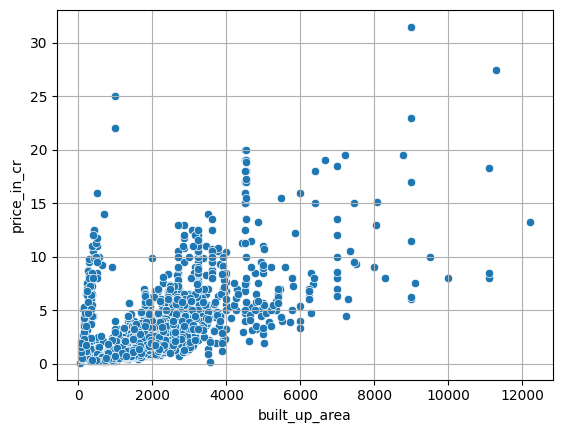

In [ ]:
# scatter plot to check any anomaly with price and builtup area relation

sns.scatterplot(x = df['built_up_area'], y = df['price_in_cr'])
plt.grid()

- scatter plot indicate some of the properties with very small builtup area but unusually high price

In [57]:
# properties with less built_up_area < 2000 and price > 2.5cr

anomaly_df = df[(df['built_up_area'] < 2000) & (df['price_in_cr'] > 2.5)]

In [58]:
anomaly_df[['price_in_cr', 'area', 'built_up_area']].sample(10)

,price_in_cr,area,built_up_area
2685,2.64,2251.60,1750.75
422,2.55,1650.06,1463.00
700,2.68,1556.96,1557.00
745,9.50,4914.00,546.00
798,2.79,1860.00,1558.00
631,5.25,1934.98,1935.00
1308,6.25,1800.01,1800.00
1010,3.15,2152.82,222.00
2250,6.40,3150.07,349.00
2496,2.90,2003.04,1821.00


In [63]:
# replacing builtup area with area in these rows

anomaly_df['built_up_area'] = anomaly_df['area']

In [64]:
df.update(anomaly_df)

<Axes: xlabel='built_up_area', ylabel='price_in_cr'>

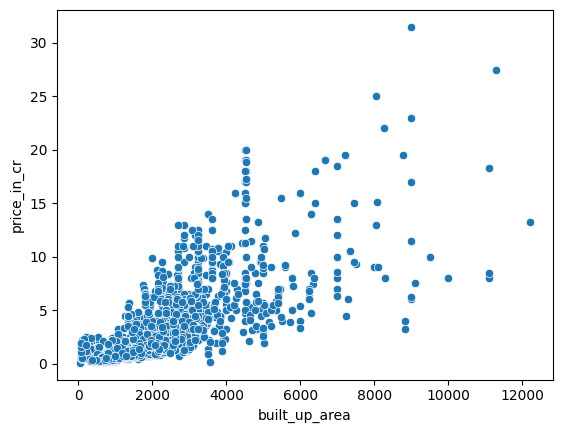

In [65]:
# plotting scatter plot again to if the anomalies have been removed

sns.scatterplot(x = df['built_up_area'], y= df['price_in_cr'])

In [67]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price_in_cr               0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 15
facing                  997
agePossession             0
super_built_up_area    1599
built_up_area             0
carpet_area            1672
servant room              0
study room                0
pooja room                0
store room                0
others                    0
furnishing_type           0
luxury_score            390
area_bedroom_ratio        0
dtype: int64

In [68]:
# drop the other columns related to area

df.drop(columns = ['area', 'areaWithType', 'super_built_up_area', 'carpet_area', 'area_bedroom_ratio'], inplace = True)

In [69]:
df.head()

,property_type,society,sector,price_in_cr,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score
0,flat,vatika gurgaon,sector 83,1.18,6801.00,3,3,2,14.0,north,relatively new,1612.0,0,0,0,0,0,1,16.0
1,flat,emaar digihomes,sector 62,4.00,14870.99,3,3,3,18.0,north,new,2353.0,1,0,0,0,0,0,40.0
2,flat,ss the leaf,sector 85,1.10,6317.99,2,2,3+,3.0,south-east,relatively new,1459.0,0,0,0,1,0,1,117.0
3,flat,tarc maceo,sector 91,0.89,6338.99,2,2,3+,9.0,east,relatively new,1297.0,0,0,0,0,1,0,9.0
4,flat,rwa,sector 7,0.48,6000.00,3,2,1,1.0,north-east,new,889.0,0,0,0,0,0,1,12.0


In [70]:
df.isnull().sum()

property_type        0
society              1
sector               0
price_in_cr          0
price_per_sqft       0
bedRoom              0
bathroom             0
balcony              0
floorNum            15
facing             997
agePossession        0
built_up_area        0
servant room         0
study room           0
pooja room           0
store room           0
others               0
furnishing_type      0
luxury_score       390
dtype: int64

### floorNum

In [71]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price_in_cr,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score
245,house,independent,sector 24,1.45,2983.54,3,3,1,NaN,NaN,old,540.0,0,0,0,0,0,1,9.0
368,house,independent,sector 2,5.60,17284.00,8,6,3+,NaN,South-West,relatively old,3240.0,1,1,1,1,0,1,NaN
544,house,ansal sushant lok,sector 43,10.50,27910.98,4,4,2,NaN,North-East,old,3762.0,1,0,0,0,0,1,46.0
786,house,vipul tatvam villa,sector 48,8.50,26234.97,4,4,2,NaN,East,relatively old,3240.0,1,0,1,1,0,1,68.0
1081,house,emaar mgf marbella,sector 66,9.00,21251.02,4,4,3+,NaN,South-West,relatively new,5200.0,1,0,1,1,0,0,97.0
1362,house,independent,sector 26,4.60,12198.00,4,4,3+,NaN,NaN,old,3771.0,0,0,0,0,0,1,14.0
1500,house,independent,sector 3,1.50,10288.00,3,3,0,NaN,NaN,old,210.0,0,0,0,0,0,1,NaN
1658,flat,experion heartsong,sector 104,1.08,6149.99,3,3,0,NaN,NaN,under construction,1758.0,0,0,0,0,0,1,NaN
2320,house,independent,sector 25,13.00,45709.95,6,8,3+,NaN,NaN,relatively new,2844.0,1,1,1,1,0,2,NaN
2478,house,independent,sector 3,4.12,8889.00,2,1,3+,NaN,NaN,relatively old,4635.0,0,0,0,0,0,1,NaN


- only 2 rows where floor num is missing are flats. remaining properties are houses
- will impute the values with 'median values of number of floors for houses'.

In [72]:
df[df['property_type'] == 'house']['floorNum'].median()

np.float64(2.0)

In [74]:
df['floorNum'] = df['floorNum'].fillna(2.0)

In [75]:
df.isnull().sum()

property_type        0
society              1
sector               0
price_in_cr          0
price_per_sqft       0
bedRoom              0
bathroom             0
balcony              0
floorNum             0
facing             997
agePossession        0
built_up_area        0
servant room         0
study room           0
pooja room           0
store room           0
others               0
furnishing_type      0
luxury_score       390
dtype: int64

### facing column

([<matplotlib.patches.Wedge at 0x1b523631400>,
 [Text(0.901616829529929, 0.6301484687820792, ''),
  Text(-0.2538020714619126, 1.070319815999705, ''),
  Text(-1.017779925111711, 0.41728170824947497, ''),
  Text(-1.072354850907235, -0.24506136728526173, ''),
  Text(-0.8437323933851947, -0.7057730855965615, ''),
  Text(-0.48215290693543333, -0.9887004472203457, ''),
  Text(-0.0917060789629408, -1.096170604915696, ''),
  Text(0.27791620449113213, -1.0643131979268337, ''),
  Text(0.599816797824419, -0.9220736462168628, ''),
  Text(0.8499004950551469, -0.698333121443496, ''),
  Text(0.993787905077053, -0.47157777696002884, ''),
  Text(1.0548747689581026, -0.31183204103425627, ''),
  Text(1.0795152202328537, -0.2112981052579821, ''),
  Text(1.0904612260463298, -0.14454865786141147, ''),
  Text(1.0969852531607578, -0.08138399319171077, ''),
  Text(1.099719259898626, -0.024850541402920957, '')],
 [Text(0.4917909979254158, 0.3437173466084068, '19.42%'),
  Text(-0.13843749352467957, 0.58381080872

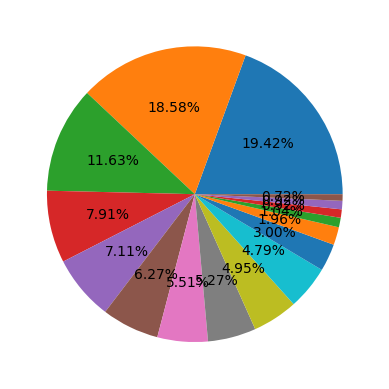

In [77]:
plt.pie(df['facing'].value_counts(), autopct='%0.2f%%')

In [78]:
df['facing'].value_counts()

facing
north-east    486
east          465
north         291
south         198
west          178
north-west    157
south-east    138
south-west    132
North-East    124
East          120
North          75
West           49
North-West     26
South-East     23
South          23
South-West     18
Name: count, dtype: int64

In [81]:
df['facing'] = df['facing'].str.strip().str.lower()

<Axes: >

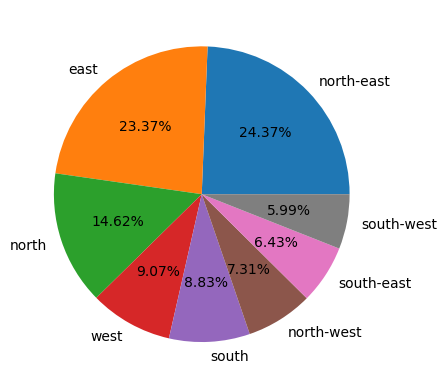

In [86]:
df['facing'].value_counts().plot(kind = 'pie', autopct = '%0.2f%%')

<Axes: xlabel='facing', ylabel='price_in_cr'>

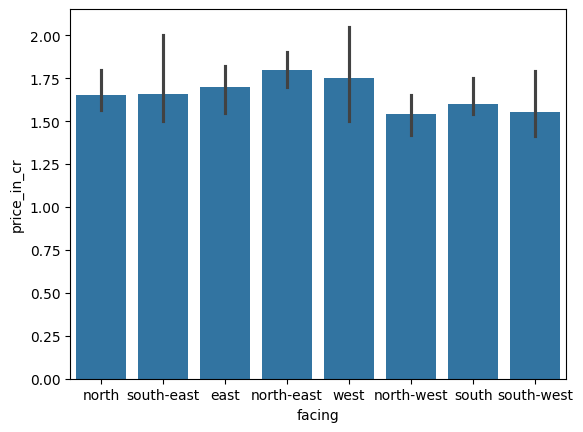

In [88]:
sns.barplot(x = df['facing'], y = df['price_in_cr'], estimator='median')

In [89]:
df.head()

,property_type,society,sector,price_in_cr,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score
0,flat,vatika gurgaon,sector 83,1.18,6801.00,3,3,2,14.0,north,relatively new,1612.0,0,0,0,0,0,1,16.0
1,flat,emaar digihomes,sector 62,4.00,14870.99,3,3,3,18.0,north,new,2353.0,1,0,0,0,0,0,40.0
2,flat,ss the leaf,sector 85,1.10,6317.99,2,2,3+,3.0,south-east,relatively new,1459.0,0,0,0,1,0,1,117.0
3,flat,tarc maceo,sector 91,0.89,6338.99,2,2,3+,9.0,east,relatively new,1297.0,0,0,0,0,1,0,9.0
4,flat,rwa,sector 7,0.48,6000.00,3,2,1,1.0,north-east,new,889.0,0,0,0,0,0,1,12.0


- will drop facing column as too many missing values and no real impact on price

In [90]:
df.drop(columns = 'facing', inplace = True)

In [91]:
df.isnull().sum()

property_type        0
society              1
sector               0
price_in_cr          0
price_per_sqft       0
bedRoom              0
bathroom             0
balcony              0
floorNum             0
agePossession        0
built_up_area        0
servant room         0
study room           0
pooja room           0
store room           0
others               0
furnishing_type      0
luxury_score       390
dtype: int64

- luxury_score

In [95]:
temp_df= df[~df['luxury_score'].isnull()]

<Axes: xlabel='luxury_score', ylabel='price_in_cr'>

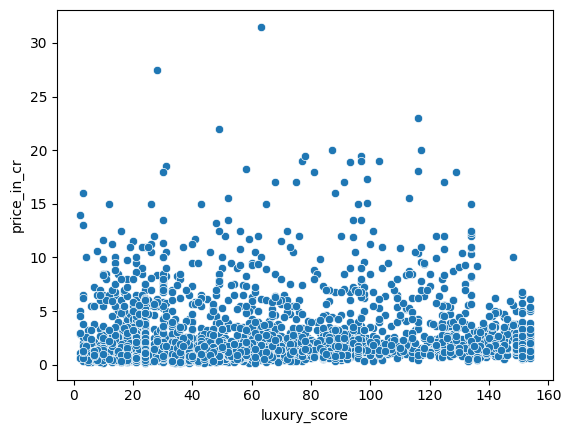

In [96]:
sns.scatterplot(x = temp_df['luxury_score'], y = temp_df['price_in_cr'])

<Axes: xlabel='luxury_score', ylabel='price_per_sqft'>

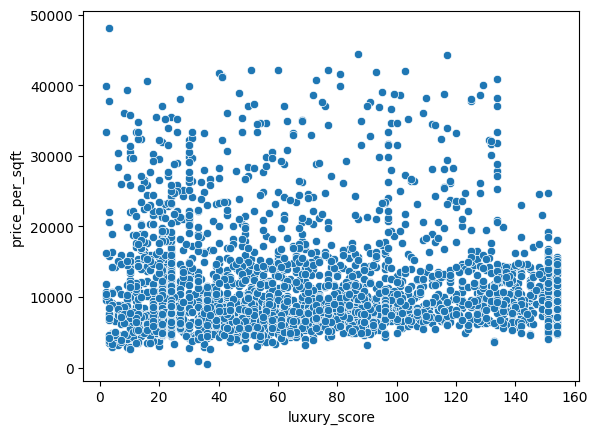

In [105]:
sns.scatterplot(x = temp_df['luxury_score'], y = temp_df['price_per_sqft'])

In [111]:
df['luxury_score'].describe()

count    3110.000000
mean       66.443087
std        44.155736
min         2.000000
25%        24.000000
50%        58.000000
75%        97.000000
max       154.000000
Name: luxury_score, dtype: float64

- no evident direct relation b/w luxury score and price. This could be due to other factors like sector etc
- Try Random forrest to impute the missing values

In [104]:
df.head()

,property_type,society,sector,price_in_cr,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score
0,flat,vatika gurgaon,sector 83,1.18,6801.00,3,3,2,14.0,relatively new,1612.0,0,0,0,0,0,1,16.0
1,flat,emaar digihomes,sector 62,4.00,14870.99,3,3,3,18.0,new,2353.0,1,0,0,0,0,0,40.0
2,flat,ss the leaf,sector 85,1.10,6317.99,2,2,3+,3.0,relatively new,1459.0,0,0,0,1,0,1,117.0
3,flat,tarc maceo,sector 91,0.89,6338.99,2,2,3+,9.0,relatively new,1297.0,0,0,0,0,1,0,9.0
4,flat,rwa,sector 7,0.48,6000.00,3,2,1,1.0,new,889.0,0,0,0,0,0,1,12.0


In [ ]:
from sklearn.ensemble import RandomForestRegressor

train_df = df[~df['luxury_score'].isnull()]     # random forest will be trained on available luxuryscore rows
test_df = df[df['luxury_score'].isnull()]

features = ['property_type', 'society', 'sector', 'price_per_sqft', 'bedRoom', 'bathroom', 'balcony', 'agePossession', 'built_up_area', 'furnishing_type']

# encoding train and test
train_encoded = pd.get_dummies(train_df[features], drop_first=True)
test_encoded = pd.get_dummies(test_df[features], drop_first=True)

# reindex to match the columns in encoded train and test
test_encoded = test_encoded.reindex(columns = train_encoded.columns, fill_value=0)

model= RandomForestRegressor()
model.fit(X = train_encoded, y = train_df['luxury_score'])      # train the model with X--> encoded df and y--> actual luxury score 

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [110]:
test_df['luxury_score'] = model.predict(test_encoded)

In [115]:
# check for feature importance to double check if random forest is logically giving good results

importances = model.feature_importances_
feature_names = train_encoded.columns

pd.DataFrame({
    'features': feature_names,
    'importances': importances.round(2)
}).sort_values(by='importances', ascending = False)

,features,importances
0,price_per_sqft,0.21
3,built_up_area,0.19
629,agePossession_relatively new,0.06
4,furnishing_type,0.05
2,bathroom,0.03
...,...,...
628,agePossession_old,0.00
15,society_aipl club residences,0.00
16,society_aipl the peaceful homes,0.00
631,agePossession_undefined,0.00


In [117]:
df.update(test_df)

In [119]:
df['luxury_score'].describe()

count    3500.000000
mean       63.713188
std        42.768375
min         2.000000
25%        24.000000
50%        54.075000
75%        91.000000
max       154.000000
Name: luxury_score, dtype: float64

In [118]:
df.isnull().sum()

property_type      0
society            1
sector             0
price_in_cr        0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
servant room       0
study room         0
pooja room         0
store room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

# society column

In [121]:
df[df['society'].isnull()]

,property_type,society,sector,price_in_cr,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score
2881,flat,NaN,sector 78,0.6,3691.99,2,2,0,2.0,under construction,1625.0,0,0,0,0,0,1,46.98


In [122]:
# since its just 1 row, therefore drop that row

df.drop(index = 2881, inplace = True)

In [123]:
df.isnull().sum()

property_type      0
society            0
sector             0
price_in_cr        0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
servant room       0
study room         0
pooja room         0
store room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

### agePossesion columns

- some of the values in agepossesion column are undefined which need to be fixed

In [ ]:
df['agePossession'].value_counts()

#297 properties, age possesion is not defined

agePossession
relatively new        1568
new                    569
relatively old         517
undefined              297
old                    277
under construction     271
Name: count, dtype: int64

In [125]:
df[df['agePossession'] == 'undefined']

,property_type,society,sector,price_in_cr,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score
16,flat,baani city center,sector 63,0.88,10945.00,1,1,2,4.0,undefined,804.0,0,0,0,0,0,1,57.42
24,flat,milan cghs 9,sector 39,2.00,8332.99,3,3,3+,0.0,undefined,2400.0,0,0,0,0,0,1,53.37
28,house,independent,sector 13,2.25,6943.99,10,10,2,1.0,undefined,400.0,0,0,0,0,0,1,11.78
36,flat,raheja vedaanta,sector 108,0.70,4521.99,2,2,3,1.0,undefined,1548.0,0,0,0,0,0,1,57.10
55,flat,godrej habitat,sector 3,1.35,12783.97,2,2,0,4.0,undefined,1056.0,0,0,0,0,0,1,50.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3459,flat,signature global park,sector 47,0.87,7190.02,3,2,3,4.0,undefined,1210.0,0,0,0,0,0,1,55.00
3467,flat,chd avenue,sector 71,0.95,7917.00,2,2,0,5.0,undefined,1200.0,0,0,0,0,0,1,60.08
3471,house,independent,sector 3a,0.55,7333.04,1,1,0,1.0,undefined,750.0,0,0,0,0,0,1,11.42
3488,flat,spaze privy,sector 72,1.90,9620.01,3,3,3,10.0,undefined,1975.0,0,0,0,0,0,1,58.61


- will impuet agepossesion based on mode of property type and sector for each row
- since some of the some sectors are new or old. 

In [131]:
df['agePossession'] = df['agePossession'].replace('undefined', np.nan)

df['agePossession'] = df.groupby(['sector', 'property_type'])['agePossession'].transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan))


In [132]:
df['agePossession'].value_counts()

agePossession
relatively new        1686
new                    632
relatively old         560
old                    328
under construction     281
Name: count, dtype: int64

<Axes: >

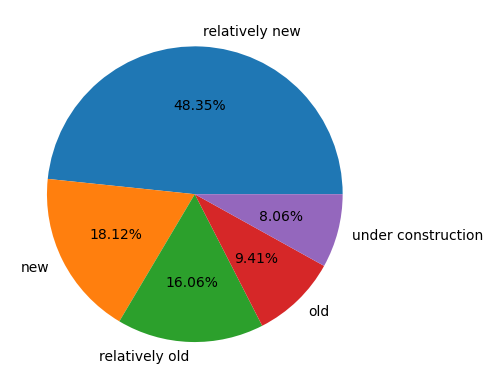

In [135]:
df['agePossession'].value_counts().plot(kind = 'pie', autopct = '%0.2f%%')

In [150]:
temp_df = df[df['agePossession'].isnull()]

In [151]:
temp_df.head()

,property_type,society,sector,price_in_cr,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score
326,flat,global hill view,sector 11,0.32,4270.99,2,2,0,11.0,NaN,761.0,0,0,0,0,0,1,41.69
370,house,independent,sector 1,1.85,16003.04,4,3,2,3.0,NaN,1284.0,0,0,0,0,0,1,22.41
445,house,independent,sector 1,4.75,10556.00,6,7,0,4.0,NaN,4500.0,0,0,0,0,0,1,22.42
464,house,sobha city,sector 108,10.50,14322.99,5,4,3+,1.0,NaN,7331.0,0,0,0,0,0,1,61.00
484,house,independent,sector 108,1.34,5000.00,1,1,0,1.0,NaN,2680.0,0,0,0,0,0,1,17.99


In [164]:
def mode_based_imputation(row):
    mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
    return mode_value.iloc[0]

In [166]:
temp_df['agePossession'] = temp_df.apply(mode_based_imputation, axis = 1)

In [168]:
df.update(temp_df)

In [169]:
df['agePossession'].isnull().sum()

np.int64(0)

In [170]:
df.head()

,property_type,society,sector,price_in_cr,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score
0,flat,vatika gurgaon,sector 83,1.18,6801.00,3,3,2,14.0,relatively new,1612.0,0,0,0,0,0,1,16.0
1,flat,emaar digihomes,sector 62,4.00,14870.99,3,3,3,18.0,new,2353.0,1,0,0,0,0,0,40.0
2,flat,ss the leaf,sector 85,1.10,6317.99,2,2,3+,3.0,relatively new,1459.0,0,0,0,1,0,1,117.0
3,flat,tarc maceo,sector 91,0.89,6338.99,2,2,3+,9.0,relatively new,1297.0,0,0,0,0,1,0,9.0
4,flat,rwa,sector 7,0.48,6000.00,3,2,1,1.0,new,889.0,0,0,0,0,0,1,12.0


In [172]:
df.shape

(3499, 18)

In [173]:
df['agePossession'].value_counts()

agePossession
relatively new        1689
new                    632
relatively old         569
old                    328
under construction     281
Name: count, dtype: int64